# Moving Bar

In [27]:
import os
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [28]:
import yaml

with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [29]:
qdspy_export_dir = Path(config["qdspy"]["export_dir"])
os.listdir(qdspy_export_dir)

['RGC_MovingBar_60Hz_10um_pixels.npz',
 'RGC_MovingBar_60Hz_10um_pixels_mark.npz',
 'v2']

In [30]:
out_dir = Path(config["output_dir"])
os.makedirs(out_dir, exist_ok=True)

In [31]:
crop_setup1_h = config["qdspy"]["crop"]["setup1"]["h"]
crop_setup1_v = config["qdspy"]["crop"]["setup1"]["v"]

crop_setup3_h = config["qdspy"]["crop"]["setup3"]["h"]
crop_setup3_v = config["qdspy"]["crop"]["setup3"]["v"]

In [32]:
bar_file = 'RGC_MovingBar_60Hz_10um_pixels.npz'
bar_mark_file = 'RGC_MovingBar_60Hz_10um_pixels_mark.npz'

In [33]:
bar = np.load(os.path.join(qdspy_export_dir, bar_file))['data']
bar = np.round(np.mean(bar, axis=-1)).astype(int)
bar.shape

(2184, 120, 120)

In [34]:
bar[2*60, 0, 0]

np.int64(0)

In [35]:
bar_mark = np.load(os.path.join(qdspy_export_dir, bar_mark_file))['data']
bar_mark = np.append(bar_mark[:-1] & (~bar_mark[1:]), False)
bar_mark

array([False, False, False, ..., False, False, False], shape=(2184,))

In [36]:
time_bar = np.arange(bar.shape[0]) * 1./60.

In [37]:
def plot_mb(bar, bar_mark, time_bar):
    fig, axs = plt.subplot_mosaic(
        """
        ABCDE
        FFFFF
        """,
        figsize=(12, 4)
    )
    
    ax = axs['A']
    h, w = bar.shape[1:3]
    im = ax.imshow(np.mean(bar, axis=0), vmin=0, extent=(-w/2, w/2, h/2, -h/2), cmap='gray')
    ax.set(xlabel='left <-> right\n[pix=10 µm]', ylabel='front <-> back\n[pix=10 µm]', title='mean')
    plt.colorbar(im, ax=ax)

    all_ts = [4.3, 8.3, 12.3, 16.3]
    
    for i, t_s in enumerate(all_ts):
        ax = axs["BCDE"[i]]
        ax.set_title(f't={t_s}s')
        h, w = bar.shape[1:3]
        im = ax.imshow(bar[int(60*t_s)], vmin=0, vmax=255, extent=(-w/2, w/2, h/2, -h/2), cmap='gray')
        plt.colorbar(im, ax=ax, ticks=[0, 255])
    
    ax = axs['F']
    ax.plot(time_bar, bar[:, bar.shape[1] // 2, bar.shape[2] // 2], label='Int. @ Center')
    ax.vlines(time_bar[bar_mark], -70, -20, color='r', label='Trigger')
    ax.vlines(all_ts, ymin=260, ymax=300, color='k', label='Shown frames')
    ax.set_xticks(np.arange(int(max(time_bar))))
    ax.set(xlabel='Time [s]', ylabel='Intensity')
    ax.set_yticks([0, 100, 200, 255])
    ax.legend(loc='lower right')

    for i, deg in enumerate([0, 180, 45, 225, 90, 270, 135, 315]):
        ax.text((4.5+4*i), 260, f"{deg}°", ha='left', va='bottom')

    plt.tight_layout()
    
    return fig, axs

In [38]:
np.sum(bar_mark[:-1])

np.int64(8)

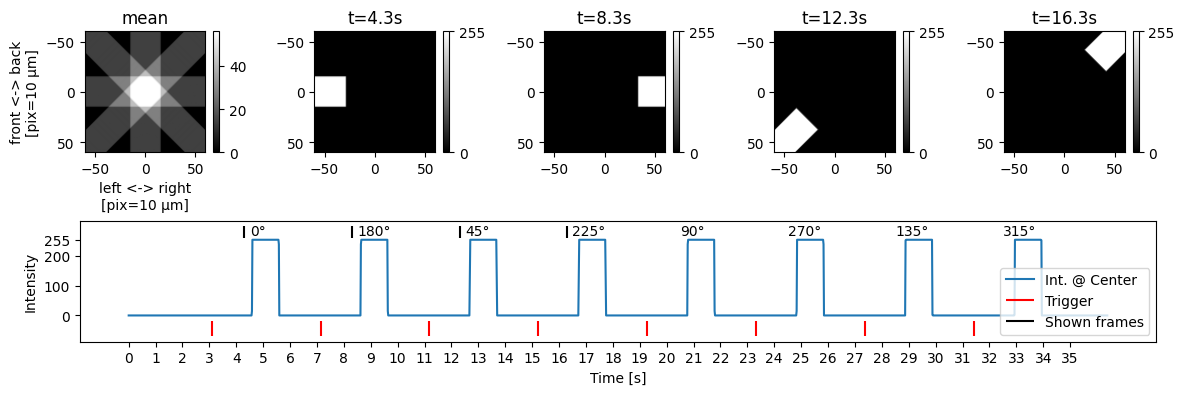

In [39]:
plot_mb(bar, bar_mark, time_bar);

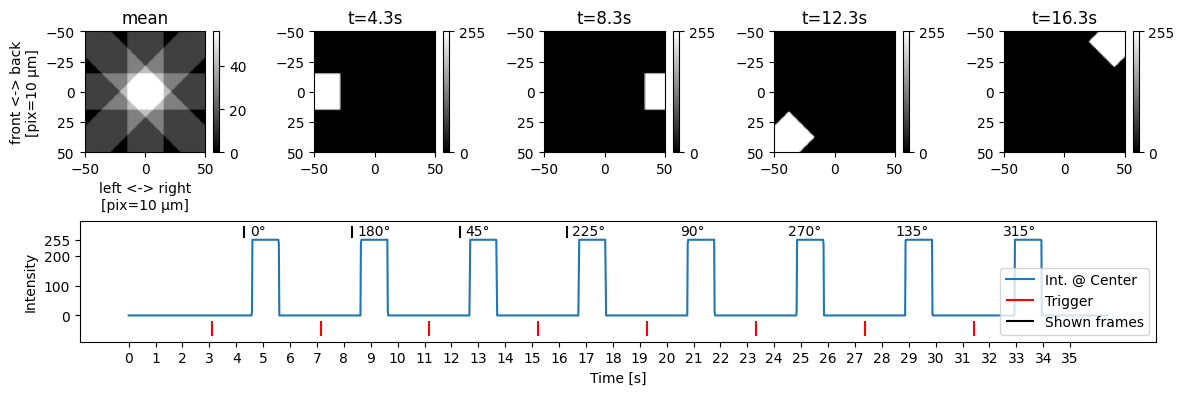

In [40]:
# →, ←, ↗, ↙, ↑, ↓, ↖, ↘
RGC_MovingBar_setup1 = bar[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
fig, axs = plot_mb(RGC_MovingBar_setup1, bar_mark, time_bar)
plt.savefig(os.path.join(out_dir, 'RGC_MovingBar_setup1.pdf'), bbox_inches='tight')

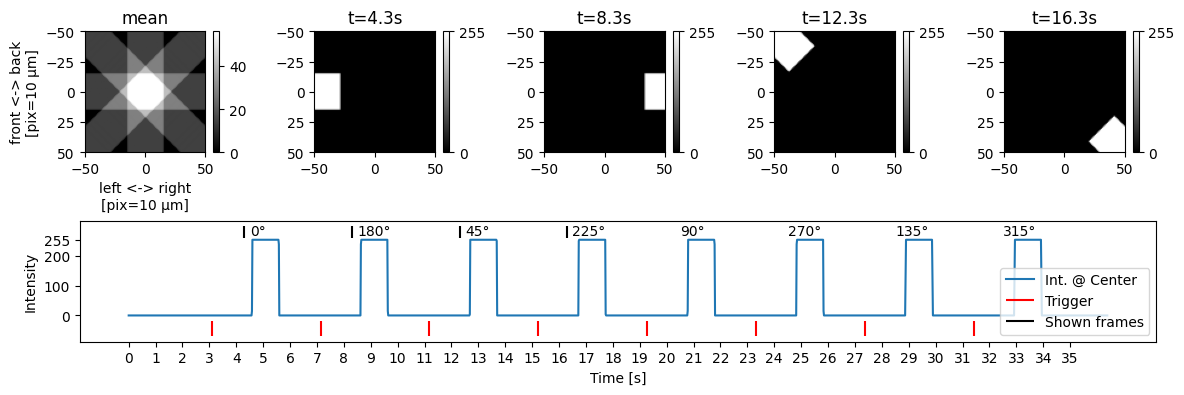

In [41]:
# →, ←, ↘, ↖, ↓, ↑, ↙, ↗
RGC_MovingBar_setup3 = np.flip(bar, axis=1)[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]
fig, axs = plot_mb(RGC_MovingBar_setup3, bar_mark, time_bar)
plt.savefig(os.path.join(out_dir, 'RGC_MovingBar_setup3.pdf'), bbox_inches='tight')

In [42]:
assert np.all(RGC_MovingBar_setup3.astype(np.uint8) == RGC_MovingBar_setup3)

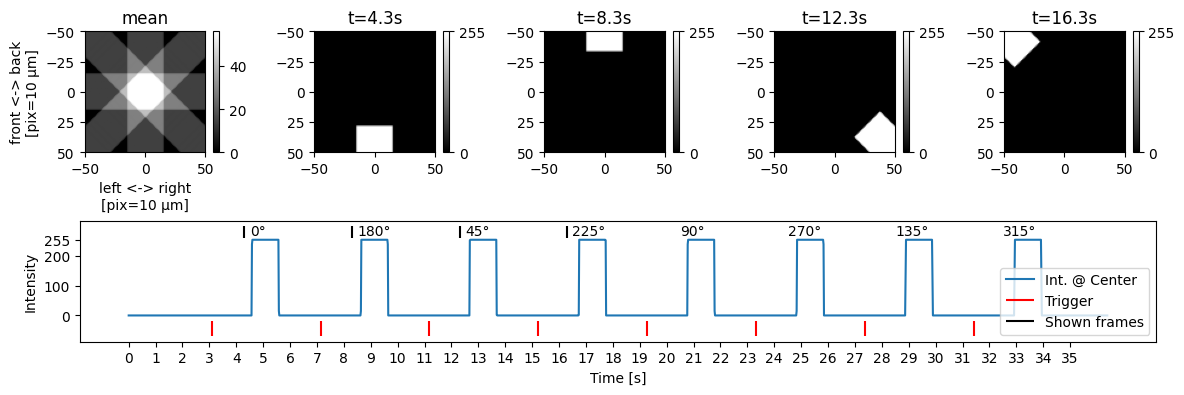

In [43]:
# ↑, ↓, ↖, ↘, ←, →, ↙, ↗
DS_setup1 = np.rot90(bar, k=1, axes=(1, 2))[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
fig, axs = plot_mb(DS_setup1, bar_mark, time_bar)
plt.savefig(os.path.join(out_dir, 'DS_setup1.pdf'), bbox_inches='tight')

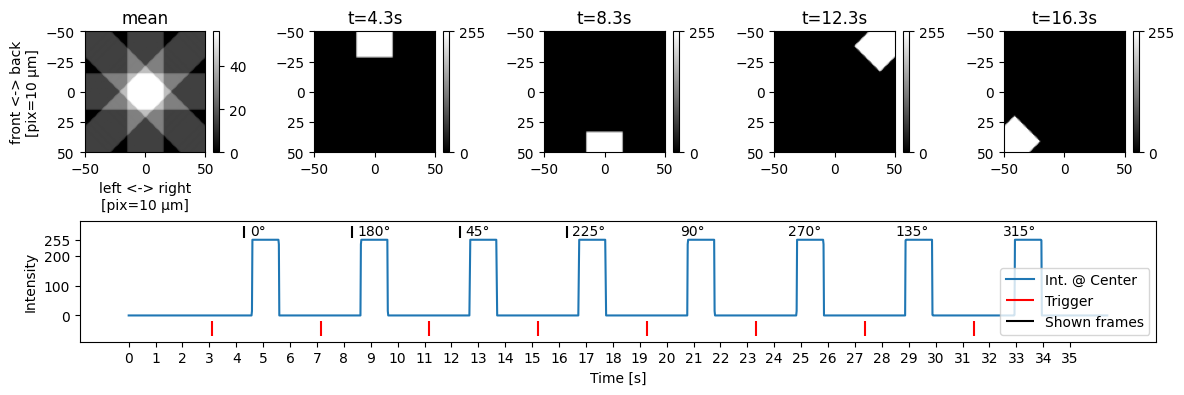

In [44]:
# ↓, ↑, ↙, ↗, ←, →, ↖, ↘
DS_setup3 = np.rot90(np.flip(bar, axis=2), k=1, axes=(1, 2))[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]
fig, axs = plot_mb(DS_setup3, bar_mark, time_bar)
plt.savefig(os.path.join(out_dir, 'DS_setup3.pdf'), bbox_inches='tight')

In [45]:
target_freq = 60
assert np.isclose(target_freq, np.round(1 / np.mean(np.diff(time_bar))))

for stim, setup, name in [
    (RGC_MovingBar_setup1, '1', 'RGC_MovingBar'),
    (RGC_MovingBar_setup3, '3', 'RGC_MovingBar'),
    (DS_setup1, '1', 'DS'),
    (DS_setup3, '3', 'DS')
]:
    assert np.all(stim.astype(np.uint8) == stim)
    np.savez_compressed(
        os.path.join(out_dir, f'{name}_setup{setup}_movie_and_trigger'),
        stimulus=stim.astype(np.uint8),
        time=time_bar.astype(np.float32),
        trigger=bar_mark,
        framerate=target_freq,
    )